In [ ]:
# =============================================================================
# FastUMI HDF5 Data Structure Analysis & Visualization
# 每个episode是独立的HDF5文件
# =============================================================================

## 📦 Import Dependencies

In [1]:
from pathlib import Path
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

## 📊 Data Structure Overview

In [2]:
# 设置数据路径
data_root = Path('/mnt/raid0/UMI2Lerobot/rawData/FastUMI_extracted')
task_name = 'clean_table_v1'
task_dir = data_root / task_name

# 获取所有episode文件
episode_files = sorted(task_dir.glob('episode_*.hdf5'))
print(f'\n{"="*60}')
print(f'📂 Task: {task_name}')
print(f'🎬 Total Episodes: {len(episode_files)}')
print(f'📁 Episode Files: {episode_files[0].name} ~ {episode_files[-1].name}')
print(f'{"="*60}\n')


📂 Task: clean_table_v1
🎬 Total Episodes: 50
📁 Episode Files: episode_1.hdf5 ~ episode_9.hdf5



In [3]:
# 查看单个episode的结构
episode_path = episode_files[0]
print(f'📄 分析文件: {episode_path.name}\n')

with h5py.File(episode_path, 'r') as f:
    print(f'Top-level Keys: {list(f.keys())}\n')
    
    # 收集数据信息
    data_info = []
    
    def collect_info(name, obj):
        if isinstance(obj, h5py.Dataset):
            shape = obj.shape
            dtype = str(obj.dtype)
            
            # 判断数据类型
            if dtype == 'uint8' and len(shape) == 4:
                data_type = 'Image Sequence'
                frame_size = f'{shape[1]}x{shape[2]}x{shape[3]}'
                count = f'{shape[0]} frames'
            else:
                data_type = 'Numeric Sequence'
                frame_size = f'{shape[-1]}D' if len(shape) > 1 else 'Scalar'
                count = str(shape)
            
            data_info.append({
                'Field': f'📷 {name}' if data_type == 'Image Sequence' else f'🦾 {name}',
                'Type': data_type,
                'Count/Shape': count,
                'Frame Size': frame_size,
                'Data Type': dtype
            })
    
    f.visititems(collect_info)
    
    # 显示结果
    df = pd.DataFrame(data_info)
    display(HTML(f'<h4>🗂️ {episode_path.name} Data Structure</h4>'))
    display(df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
        [{'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#4a4a4a'), ('color', 'white')]}]
    ))

📄 分析文件: episode_1.hdf5

Top-level Keys: ['action', 'observations']



,Field,Type,Count/Shape,Frame Size,Data Type
0,🦾 action,Numeric Sequence,"(180, 7)",7D,float32
1,📷 observations/images/front,Image Sequence,180 frames,1080x1920x3,uint8
2,🦾 observations/qpos,Numeric Sequence,"(180, 7)",7D,float32


## 📈 Episode Statistics

Episode 长度统计:
  最短: 180 frames
  最长: 180 frames
  平均: 180.0 frames
  总帧数: 9000 frames


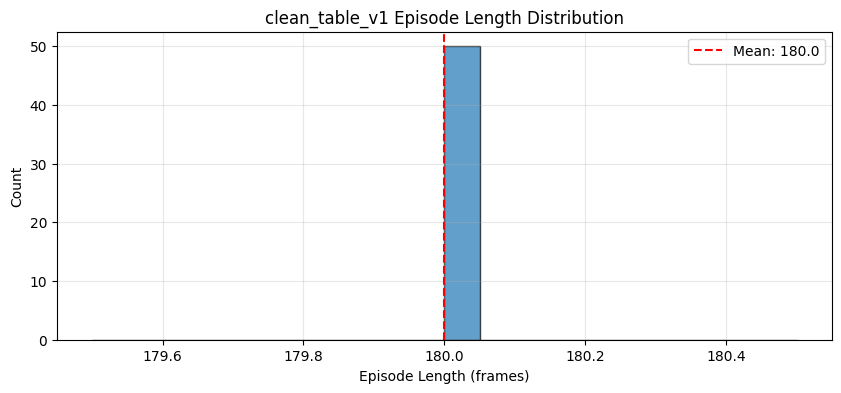

In [11]:
# 统计所有episode的长度
episode_lengths = []
for ep_file in episode_files:
    with h5py.File(ep_file, 'r') as f:
        episode_lengths.append(f['action'].shape[0])

print(f'Episode 长度统计:')
print(f'  最短: {min(episode_lengths)} frames')
print(f'  最长: {max(episode_lengths)} frames')
print(f'  平均: {np.mean(episode_lengths):.1f} frames')
print(f'  总帧数: {sum(episode_lengths)} frames')

# 绘制直方图
plt.figure(figsize=(10, 4))
plt.hist(episode_lengths, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Episode Length (frames)')
plt.ylabel('Count')
plt.title(f'{task_name} Episode Length Distribution')
plt.axvline(np.mean(episode_lengths), color='r', linestyle='--', label=f'Mean: {np.mean(episode_lengths):.1f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 🖼️ Visualize Episode

Episode: episode_1.hdf5
  Images shape: (180, 1080, 1920, 3)
  Actions shape: (180, 7)
  Qpos shape: (180, 7)


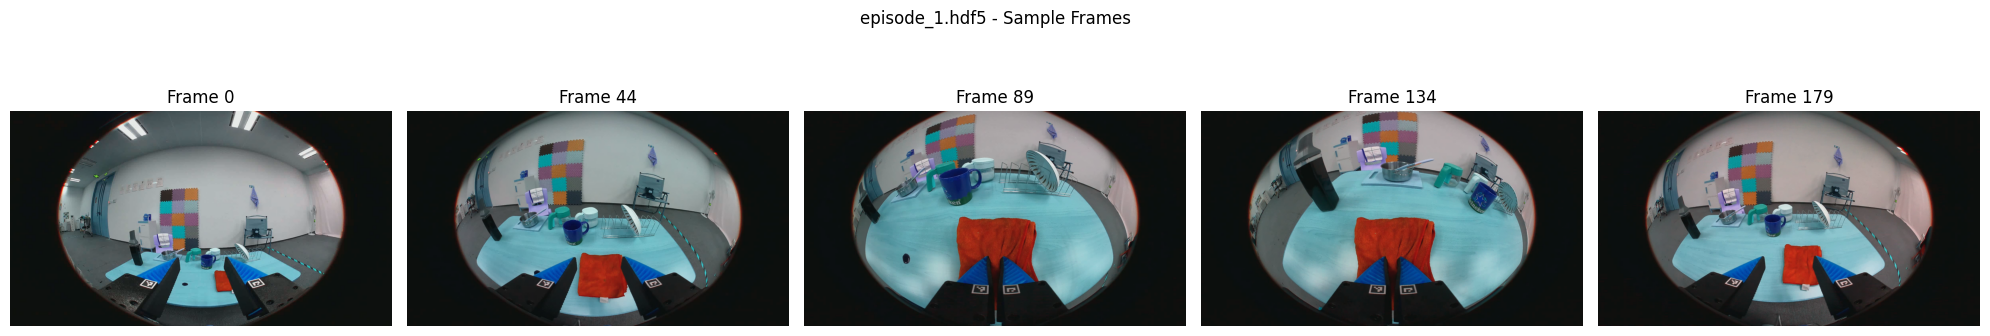

In [12]:
# 可视化某个episode的图像
episode_idx = 0  # 选择第几个episode
episode_path = episode_files[episode_idx]

with h5py.File(episode_path, 'r') as f:
    images = f['observations/images/front'][:]
    actions = f['action'][:]
    qpos = f['observations/qpos'][:]
    
    print(f'Episode: {episode_path.name}')
    print(f'  Images shape: {images.shape}')
    print(f'  Actions shape: {actions.shape}')
    print(f'  Qpos shape: {qpos.shape}')
    
    # 显示几帧图像
    n_frames = min(5, len(images))
    fig, axes = plt.subplots(1, n_frames, figsize=(20, 4))
    indices = np.linspace(0, len(images)-1, n_frames, dtype=int)
    
    for i, idx in enumerate(indices):
        axes[i].imshow(images[idx])
        axes[i].set_title(f'Frame {idx}')
        axes[i].axis('off')
    
    plt.suptitle(f'{episode_path.name} - Sample Frames')
    plt.tight_layout()
    plt.show()

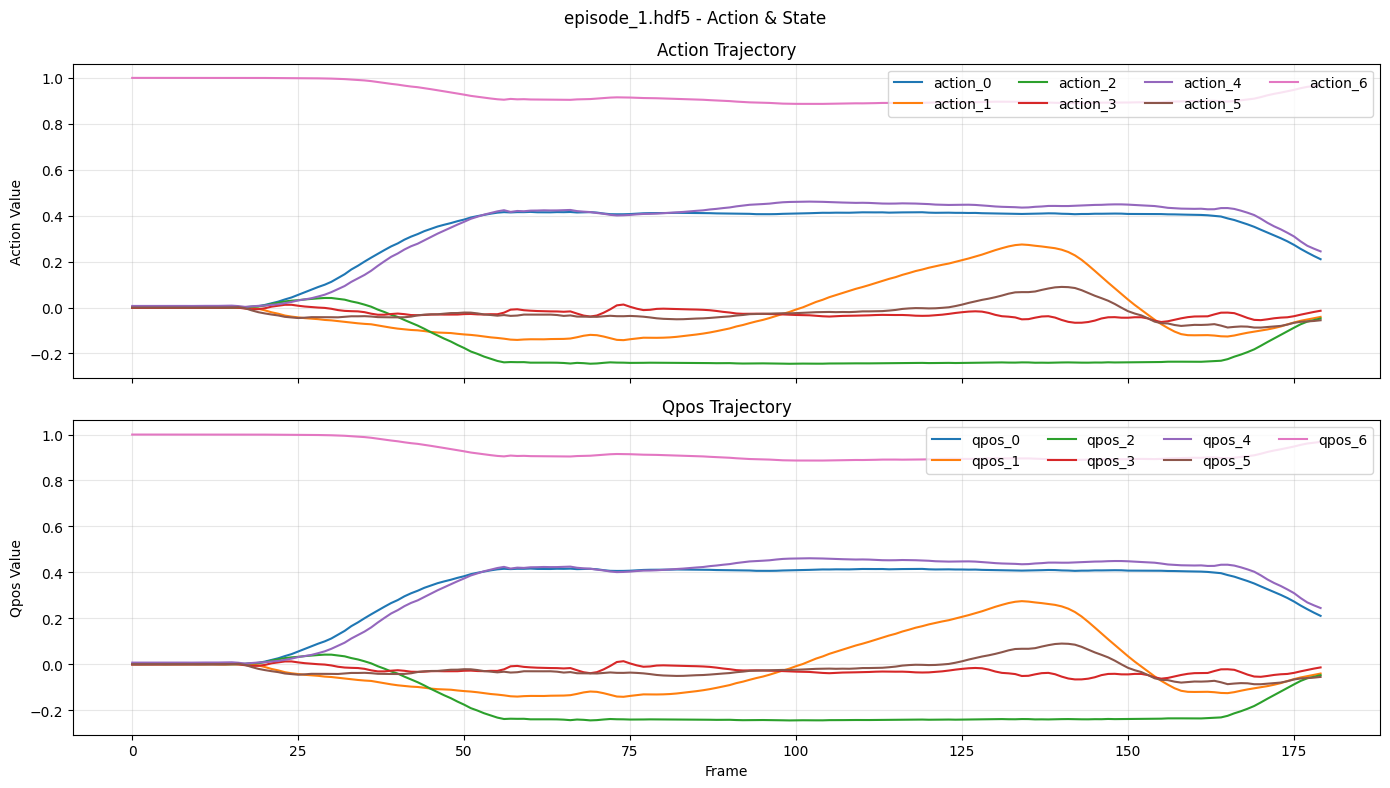

In [13]:
# 绘制动作和状态曲线
with h5py.File(episode_files[0], 'r') as f:
    actions = f['action'][:]
    qpos = f['observations/qpos'][:]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 动作
for i in range(actions.shape[1]):
    axes[0].plot(actions[:, i], label=f'action_{i}')
axes[0].set_ylabel('Action Value')
axes[0].set_title('Action Trajectory')
axes[0].legend(loc='upper right', ncol=4)
axes[0].grid(True, alpha=0.3)

# 状态
for i in range(qpos.shape[1]):
    axes[1].plot(qpos[:, i], label=f'qpos_{i}')
axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Qpos Value')
axes[1].set_title('Qpos Trajectory')
axes[1].legend(loc='upper right', ncol=4)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{episode_files[0].name} - Action & State')
plt.tight_layout()
plt.show()

## 📋 All Tasks Overview

In [8]:
# 列出所有任务
all_tasks = sorted([d.name for d in data_root.iterdir() if d.is_dir()])
print(f'Total tasks: {len(all_tasks)}\n')

task_stats = []
for task in all_tasks[:20]:  # 只显示前20个任务
    task_dir = data_root / task
    episodes = list(task_dir.glob('episode_*.hdf5'))
    task_stats.append({
        'Task': task,
        'Episodes': len(episodes)
    })

df = pd.DataFrame(task_stats)
display(df)

Total tasks: 194



,Task,Episodes
0,clean_table_v0,50
1,clean_table_v1,50
2,clean_table_v2,50
3,clean_table_v3,50
4,clean_table_v4,15
5,close_ricecooker_v0,20
6,cover_beef_v0,50
7,cover_beef_v1,50
8,cover_beef_v10,17
9,cover_beef_v2,50
